# Mount Folder ke GDrive

In [ ]:
from google.colab import drive
import os
import sys

#izin akses ke drive
drive.mount('/content/drive')

# declare path
PROJECT_ROOT = '/content/drive/MyDrive/Keperluan TA'

sys.path.append(PROJECT_ROOT)

Mounted at /content/drive


# Library Uses
### Cek GPU

In [ ]:
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split

from models.load_model_TA import build_unbcsm
from keras.optimizers import SGD, Adam
from scripts.data_generator_v2 import ConjunctivaDataGenerator

(682, 512, 3)


# Define Path buat Dataset (Image & GT-nya)

In [ ]:
def get_eyedefy_paths(dataset_root):
    image_paths = []
    mask_paths = []
    countries = ['India', 'Italy']

    for country in countries:
        country_path = os.path.join(dataset_root, country)
        if not os.path.exists(country_path):
            continue

        subfolders = [f.path for f in os.scandir(country_path) if f.is_dir()]

        for subfolder in subfolders:
            mask_search = glob.glob(os.path.join(subfolder, '*_forniceal_palpebral.*'))
            if len(mask_search) > 0:
                mask_file = mask_search[0]
                base_name = os.path.basename(mask_file).split('_forniceal_palpebral')[0]

                # Skenario 1: Nama persis sama
                original_img_file_1 = os.path.join(subfolder, base_name + '.jpg')

                # Skenario 2: Angka 0 di depan dihilangkan
                base_name_stripped = base_name.lstrip('0') or '0'
                original_img_file_2 = os.path.join(subfolder, base_name_stripped + '.jpg')

                if os.path.exists(original_img_file_1):
                    image_paths.append(original_img_file_1)
                    mask_paths.append(mask_file)
                elif os.path.exists(original_img_file_2):
                    image_paths.append(original_img_file_2)
                    mask_paths.append(mask_file)
                else:
                    # Skenario 3
                    for jpg in glob.glob(os.path.join(subfolder, '*.jpg')):
                        if 'forniceal' not in jpg and 'palpebral' not in jpg:
                            image_paths.append(jpg)
                            mask_paths.append(mask_file)
                            break

    return image_paths, mask_paths

EYEDEFY_ROOT = os.path.join(PROJECT_ROOT, "dataset", "Dataset Eyedefy") #path folder dataset -> Dataset Eyedefy

images, masks = get_eyedefy_paths(EYEDEFY_ROOT)

print(f"Total data di Google Drive: {len(images)} pasang gambar dan mask.")

Total data di Google Drive: 211 pasang gambar dan mask.


# Copy Dataset ke Local Colab

In [ ]:
import shutil

LOCAL_IMG_DIR = '/content/local_dataset/images'
LOCAL_MASK_DIR = '/content/local_dataset/masks'
os.makedirs(LOCAL_IMG_DIR, exist_ok=True)
os.makedirs(LOCAL_MASK_DIR, exist_ok=True)

local_image_paths = []
local_mask_paths = []

print("\nCopy-ing dataset ke Local Colab...")
for i, (img_path, mask_path) in enumerate(zip(images, masks)):
    # file name buat di local colab
    img_new_name = f"img_{i}_{os.path.basename(img_path)}"
    mask_new_name = f"mask_{i}_{os.path.basename(mask_path)}"

    new_img_path = os.path.join(LOCAL_IMG_DIR, img_new_name)
    new_mask_path = os.path.join(LOCAL_MASK_DIR, mask_new_name)

    # copy dari gdrive ke local colab declaration code
    shutil.copy2(img_path, new_img_path)
    shutil.copy2(mask_path, new_mask_path)

    local_image_paths.append(new_img_path)
    local_mask_paths.append(new_mask_path)

# path baru nya jadi hasil copy ini
images = local_image_paths
masks = local_mask_paths

print("Selesai")


Copy-ing dataset ke Local Colab...
Selesai


# Split Data Train - Validation

In [ ]:
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

print(f"Jumlah Data Training   : {len(train_imgs)}")
print(f"Jumlah Data Validation : {len(val_imgs)}")

Jumlah Data Training   : 168
Jumlah Data Validation : 43


# Data Generator (Augmentasi) Declaration Code
## Augmentasi : (Rotation, Gaussian Blur, Brightness Addition)

In [ ]:
# Declaration di code nya :
# def __init__(self, image_paths, mask_paths, batch_size=8, target_size=(512, 682), augment=False):

BATCH_SIZE = 4

train_generator = ConjunctivaDataGenerator(
    train_imgs,
    train_masks,
    batch_size=BATCH_SIZE,
    target_size=(682, 512), #-> urutan .keras itu (height, width), sebelumnya format landscape (width, height)
    augment=True
)

val_generator = ConjunctivaDataGenerator(
    val_imgs,
    val_masks,
    batch_size=BATCH_SIZE,
    target_size=(682, 512),
    augment=False
)

print("Selesai")

Selesai


# Model + Loss Metrics Declaration Code

In [ ]:
input_shape = (682, 512, 3) # tinggi, lebar, channel

model = build_unbcsm(input_shape)

# Kita mendefinisikan ulang fungsi-fungsi ini menggunakan pure TensorFlow
# untuk menghindari error 'K.flatten' pada versi Keras/TF terbaru
def IoU(y_true, y_pred):
    # Mengganti K.flatten dengan tf.reshape dan memastikan tipe datanya float32
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (intersection + 1.0) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection + 1.0)

def dice_coef(y_true, y_pred):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + 1.0) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1.0)

def jacard_coef_loss(y_true, y_pred):
    return 1.0 - IoU(y_true, y_pred)

def iou_metric(y_true, y_pred):
    return IoU(y_true, y_pred)

sgd = SGD(momentum=0.9, nesterov=True)
model.compile(optimizer=sgd, loss=jacard_coef_loss, metrics=[iou_metric, dice_coef])

#adam_opt = Adam(learning_rate=0.001)
#model.compile(optimizer=adam_opt, loss=jacard_coef_loss, metrics=[iou_metric, dice_coef])

# Uncomment baris di bawah ini jika kamu ingin melihat seberapa dalam layer modelnya
model.summary()
print("Selesai")

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 682, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 682, 512,  │         12 │ input_layer[0][0] │
│ (BatchNormalizatio… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 341, 256,  │      1,792 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 341, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 341, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 170, 128,  │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 170, 128,  │        256 │ max_pooling2d[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 170, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 172, 130,  │          0 │ activation_1[0][… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 172, 130,  │     36,928 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 172, 130,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 172, 130,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 172, 130,  │          0 │ activation_1[0][… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 174, 132,  │          0 │ activation_2[0][… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 172, 130,  │     36,928 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 174, 132,  │     36,928 │ zero_padding2d_1… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 174, 132,  │          0 │ conv2d_3[0][0]  

 Total params: 26,652,781 (101.67 MB)

 Trainable params: 26,635,367 (101.61 MB)

 Non-trainable params: 17,414 (68.02 KB)

Selesai


# Callbacks Declaration Code

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler, ReduceLROnPlateau, Callback

# path tempat nyimpen weight
save_folder = os.path.join(PROJECT_ROOT, 'models', 'weights', 'simulasi')
os.makedirs(save_folder, exist_ok=True)

#atur namanya
#save_path = os.path.join(save_folder, 'model_simulasi_terbaik.keras')
save_path = os.path.join(save_folder, 'model_weight_SGD1.keras')

checkpoint = ModelCheckpoint(filepath=save_path, monitor='val_iou_metric', mode='max', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_iou_metric', patience=15, mode='max', verbose=0)

### Parameter Mbak Meitha

In [ ]:
def lr_schedule_tabel(epoch, current_lr):
    if epoch < 10: return 0.01
    elif epoch < 30: return 0.001
    elif epoch < 100: return 0.0001
    else: return 0.00001

lr_scheduler = LearningRateScheduler(lr_schedule_tabel, verbose=1)

In [ ]:
def lr_schedule_diturunkan(epoch, current_lr):
    # Turunkan LR awal dari 0.01 menjadi 0.005 atau 0.001
    if epoch < 10:
        return 0.005 # Cukup besar untuk belajar cepat, tapi tidak se-ekstrem 0.01
    elif epoch < 30:
        return 0.001
    elif epoch < 100:
        return 0.0001
    else:
        return 0.00001

lr_scheduler = LearningRateScheduler(lr_schedule_diturunkan, verbose=1)

### Adaptive LR Reduce

In [ ]:
# ReduceLROnPlateau akan memantau val_iou_metric. Jika akurasinya tidak naik selama 5 epoch (patience=5),
# ia akan secara otomatis mengalikan Learning Rate dengan 0.5 (factor=0.5).
lr_scheduler = ReduceLROnPlateau(
    monitor='val_iou_metric',
    factor=0.5,       # Potong LR jadi setengah (contoh: 0.001 -> 0.0005)
    patience=5,       # Tunggu 5 epoch mentok sebelum dipotong
    min_lr=0.00001,   # Batas terkecil LR
    verbose=1         # Print perubahan LR di layar saat dipotong
)

###Callbacks

In [ ]:
callbacks_list = [checkpoint, early_stop, lr_scheduler]

####Custom Callbacks

In [ ]:
class RealTimeMonitor(Callback):
    def __init__(self, patience):
        super(RealTimeMonitor, self).__init__()
        self.patience = patience
        self.best_val_iou = -np.inf
        self.wait = 0 # Counter untuk menghitung patience

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        # Mengambil metrik saat ini dari logs Keras
        train_iou = logs.get('iou_metric', 0)
        val_iou = logs.get('val_iou_metric', 0)

        # Logika Pengecekan Patience
        if val_iou > self.best_val_iou:
            self.best_val_iou = val_iou
            self.wait = 0 # Reset kesabaran karena model membaik
            patience_status = "IoU Val Improved"
        else:
            self.wait += 1
            patience_status = f"IoU Val not Improved (Patience: {self.wait} / {self.patience})"

        # Mencetak info ke layar secara real-time
        print(f"\nEpoch {epoch + 1}")
        print(f" IoU Training Result : {train_iou * 100:.2f}%")
        print(f" IoU Validation Result) : {val_iou * 100:.2f}% (Terbaik: {self.best_val_iou * 100:.2f}%)")
        print(f" Status Early Stop      : {patience_status}")
        print("-" * 50)

rt_monitor = RealTimeMonitor(patience=15)
callbacks_list = [checkpoint, early_stop, lr_scheduler, rt_monitor]

# Training Model

### Total Variasi Data Training

In [ ]:
EPOCHS = 120

# Menghitung total variasi gambar yang dipelajari model secara On-the-fly
total_train_images = len(train_imgs)
total_augmentations = total_train_images * EPOCHS

print(f"Jumlah Data Asli Training : {total_train_images} gambar")
print(f"Jumlah Epoch : {EPOCHS} epoch")
print(f"Total gambar (variasi) yang dipelajari :")
print(f"{total_train_images} x {EPOCHS} = {total_augmentations}")

Jumlah Data Asli Training : 168 gambar
Jumlah Epoch : 120 epoch
Total gambar (variasi) yang dipelajari :
168 x 120 = 20160


### Train Declaration Code

#### Declare Path

In [ ]:
result_path = "/content/drive/MyDrive/Keperluan TA/models/weights/simulasi"
nama_folder = os.path.join(result_path, "Hasil_Training_wParameters1")
os.makedirs(nama_folder, exist_ok=True)

#### **Declare Code untuk Save Parameters**

In [ ]:
# =======================================================
# MENYIMPAN PARAMETER TRAINING KE DALAM FILE TEXT (.txt)
# =======================================================
import datetime

# Pastikan variabel 'nama_folder' sudah dideklarasikan sebelumnya
path_log_params = os.path.join(nama_folder, "Log_Parameter_Training.txt")

with open(path_log_params, "w") as f:
    f.write("==================================================\n")
    f.write("          LOG PARAMETER TRAINING MODEL\n")
    f.write("==================================================\n")
    f.write(f"Waktu Eksekusi : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

    # 1. Info Dataset / Generator (Mengambil otomatis dari generator)
    f.write("--- INFORMASI DATA & GENERATOR ---\n")
    try:
        f.write(f"Batch Size         : {train_generator.batch_size}\n")
        f.write(f"Target Size Image  : {train_generator.target_size}\n")
        f.write(f"Total Batch Train  : {len(train_generator)}\n")
        f.write(f"Total Batch Validasi: {len(val_generator)}\n")
    except Exception as e:
        f.write("Data Generator     : (Informasi spesifik tidak ditemukan/berbeda format)\n")
    f.write("\n")

    # 2. Info Hyperparameter (Mengambil otomatis dari Model)
    f.write("--- HYPERPARAMETERS ---\n")
    f.write(f"Total Epochs       : {EPOCHS}\n")

    if model.optimizer:
        opt_name = type(model.optimizer).__name__

        # Mengambil nilai learning rate awal
        try:
            lr = model.optimizer.learning_rate.numpy()
        except:
            lr = "Diatur oleh Custom Scheduler"

        f.write(f"Optimizer          : {opt_name}\n")
        f.write(f"Initial Learn Rate : {lr}\n")

        # Cek momentum (Bila menggunakan SGD atau RMSprop)
        if hasattr(model.optimizer, 'momentum'):
            momentum = model.optimizer.momentum.numpy() if hasattr(model.optimizer.momentum, 'numpy') else model.optimizer.momentum
            f.write(f"Momentum           : {momentum}\n")

        # Cek nesterov (Bila menggunakan SGD)
        if hasattr(model.optimizer, 'nesterov'):
            nesterov = model.optimizer.nesterov
            f.write(f"Nesterov           : {nesterov}\n")
    else:
        f.write("Optimizer          : Tidak terdeteksi\n")

    f.write(f"Loss Function      : {model.loss}\n\n")

    # 3. Info Callbacks
    f.write("--- CALLBACKS YANG DIGUNAKAN ---\n")
    if callbacks_list:
        for i, cb in enumerate(callbacks_list):
            cb_name = type(cb).__name__
            f.write(f"{i+1}. {cb_name}\n")
    else:
        f.write("Tidak ada callbacks khusus.\n")

print(f"📝 File log parameter berhasil dibuat di: {path_log_params}")

📝 File log parameter berhasil dibuat di: /content/drive/MyDrive/Keperluan TA/models/weights/simulasi/Hasil_Training_wParameters1/Log_Parameter_Training.txt


#### **Training**

Training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: LearningRateScheduler setting learning rate to 0.01.
Epoch 1/120
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 873ms/step - dice_coef: 0.3810 - iou_metric: 0.2453 - loss: 0.7547
Epoch 1: val_iou_metric improved from None to 0.11184, saving model to /content/drive/MyDrive/Keperluan TA/models/weights/simulasi/model_weight_SGD1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Keperluan TA/models/weights/simulasi/model_weight_SGD1.keras

Epoch 1
 IoU Training Result : 36.32%
 IoU Validation Result) : 11.18% (Terbaik: 11.18%)
 Status Early Stop      : IoU Val Improved
--------------------------------------------------
42/42 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - dice_coef: 0.5158 - iou_metric: 0.3632 - loss: 0.6368 - val_dice_coef: 0.2009 - val_iou_metric: 0.1118 - val_loss: 0.8880 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.01.
Epoch 2/120
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 894ms/step - dice_coef: 0.7310 - iou_metric: 0.5799 - loss: 0.4201
Epoch 2: v

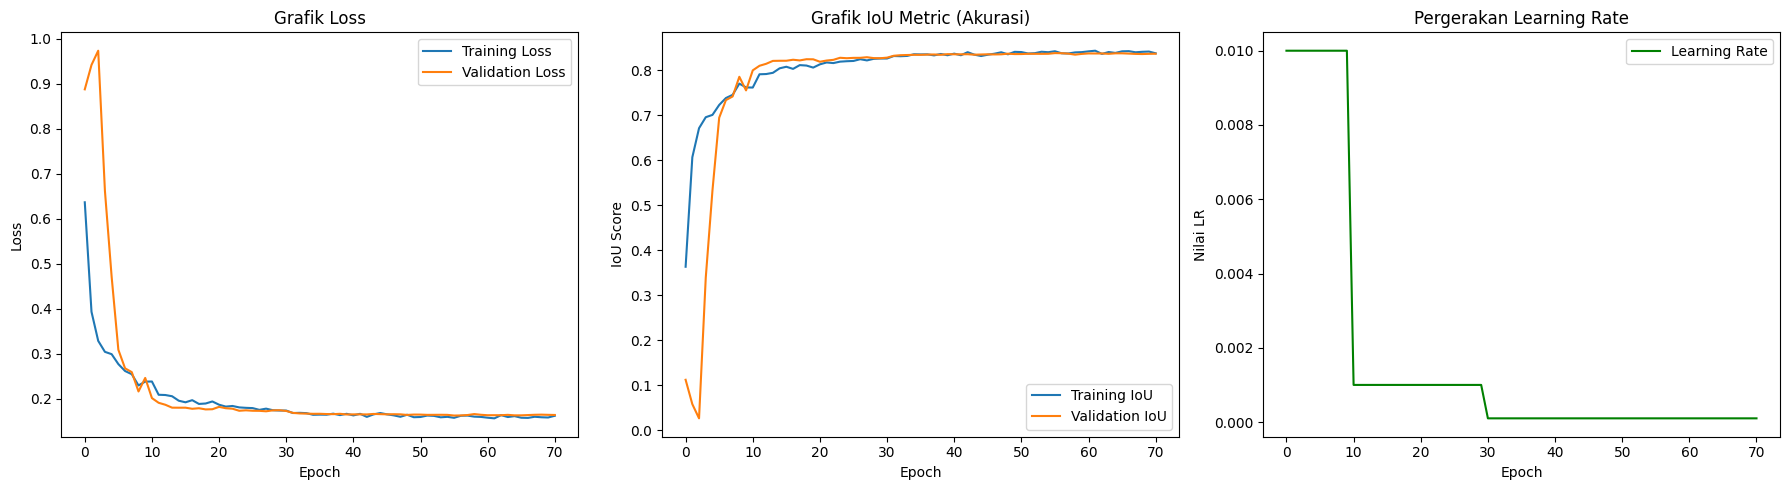

Training Selesai


In [ ]:
print("Training...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks_list
)

plt.figure(figsize=(18, 5))

# Grafik 1: Loss
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Grafik 2: IoU Akurasi
plt.subplot(1, 3, 2)
plt.plot(history.history['iou_metric'], label='Training IoU')
plt.plot(history.history['val_iou_metric'], label='Validation IoU')
plt.title('Grafik IoU Metric (Akurasi)')
plt.xlabel('Epoch')
plt.ylabel('IoU Score')
plt.legend()

# Grafik 3: Visualisasi Learning Rate ---
plt.subplot(1, 3, 3)
# Mengambil key learning rate, versi keras baru biasanya pakai 'learning_rate', versi lama 'lr'
lr_key = 'learning_rate' if 'learning_rate' in history.history else 'lr'
plt.plot(history.history[lr_key], label='Learning Rate', color='green')
plt.title('Pergerakan Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('Nilai LR')
plt.legend()

plt.tight_layout()

path_grafik_training = os.path.join(nama_folder, "Grafik_Training.png")
plt.savefig(path_grafik_training)
print(f"Grafik Hasil Training disimpan di: {path_grafik_training}")

plt.show()
print("Training Selesai")

# Testing - Validasi Hasil Training

### Library Uses - **MOUNT DULU**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import glob
from sklearn.model_selection import train_test_split

sys.path.append(os.path.join(PROJECT_ROOT, 'models'))
from load_model_TA import loadmodel2, read_image2

(682, 512, 3)


### Load Model + Weight

In [ ]:
path_model_weights = "/content/drive/MyDrive/Keperluan TA/models/weights/simulasi/model_weight_SGD1.keras"
model = loadmodel2(path_model_weights)

test_image_path = '/content/drive/MyDrive/Keperluan TA/dataset/Dataset Eyedefy/Italy/10/10.jpg'
test_mask_path = '/content/drive/MyDrive/Keperluan TA/dataset/Dataset Eyedefy/Italy/10/010_forniceal_palpebral.png'

print(f"Testing model dengan gambar: {os.path.basename(test_image_path)}")
print(f"Ground Truth mask: {os.path.basename(test_mask_path)}")

SIZE_X = 512 # Width
SIZE_Y = 682 # Height

img_resized, _, pred_mask, blended_pred = read_image2(model, test_image_path)

pred_mask_2d = np.squeeze(pred_mask, axis=-1) #(682, 512, 1) -> (682, 512)

mask_img = cv2.imread(test_mask_path, cv2.IMREAD_UNCHANGED)

if mask_img is None:
    raise ValueError(f"Error: Gagal membaca ground truth di {test_mask_path}")

if mask_img.dtype == np.uint16:
        mask_img = (mask_img / 256).astype(np.uint8)

if len(mask_img.shape) == 3 and mask_img.shape[2] == 4:
    mask_img = cv2.cvtColor(mask_img, cv2.COLOR_BGRA2RGBA)

else :
    mask_img = cv2.cvtColor(mask_img, cv2.COLOR_BGR2RGB)

mask_hsv = cv2.cvtColor(mask_img, cv2.COLOR_RGB2HSV)

saturation = mask_hsv[:, :, 1]

if np.min(mask_img) == 0:
    _, gt_mask = cv2.threshold(mask_img[:, :, 3], 0, 255, cv2.THRESH_BINARY)

else:
    _, gt_mask = cv2.threshold(saturation, 1, 255, cv2.THRESH_BINARY)

kernel = np.ones((6,6), np.uint8)
gt_mask = cv2.morphologyEx(gt_mask, cv2.MORPH_CLOSE, kernel)

gt_mask_resized = cv2.resize(gt_mask, (SIZE_X, SIZE_Y), interpolation=cv2.INTER_NEAREST)
gt_mask_biner = (gt_mask_resized > 0).astype(np.uint8)

intersection = np.logical_and(gt_mask_biner, pred_mask_2d)
union = np.logical_or(gt_mask_biner, pred_mask_2d)

iou_score = np.sum(intersection) / np.sum(union) if np.sum(union) != 0 else 0
dice_score = (2.0 * np.sum(intersection)) / (np.sum(gt_mask_biner) + np.sum(pred_mask_2d)) if (np.sum(gt_mask_biner) + np.sum(pred_mask_2d)) != 0 else 0

print(f"Akurasi IoU : {iou_score * 100:.2f} %")
print(f"Akurasi Dice Score : {dice_score * 100:.2f} %")

Testing model dengan gambar: 10.jpg
Ground Truth mask: 010_forniceal_palpebral.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
Akurasi IoU : 85.13 %
Akurasi Dice Score : 91.97 %


### Visualisasi Hasil Testing

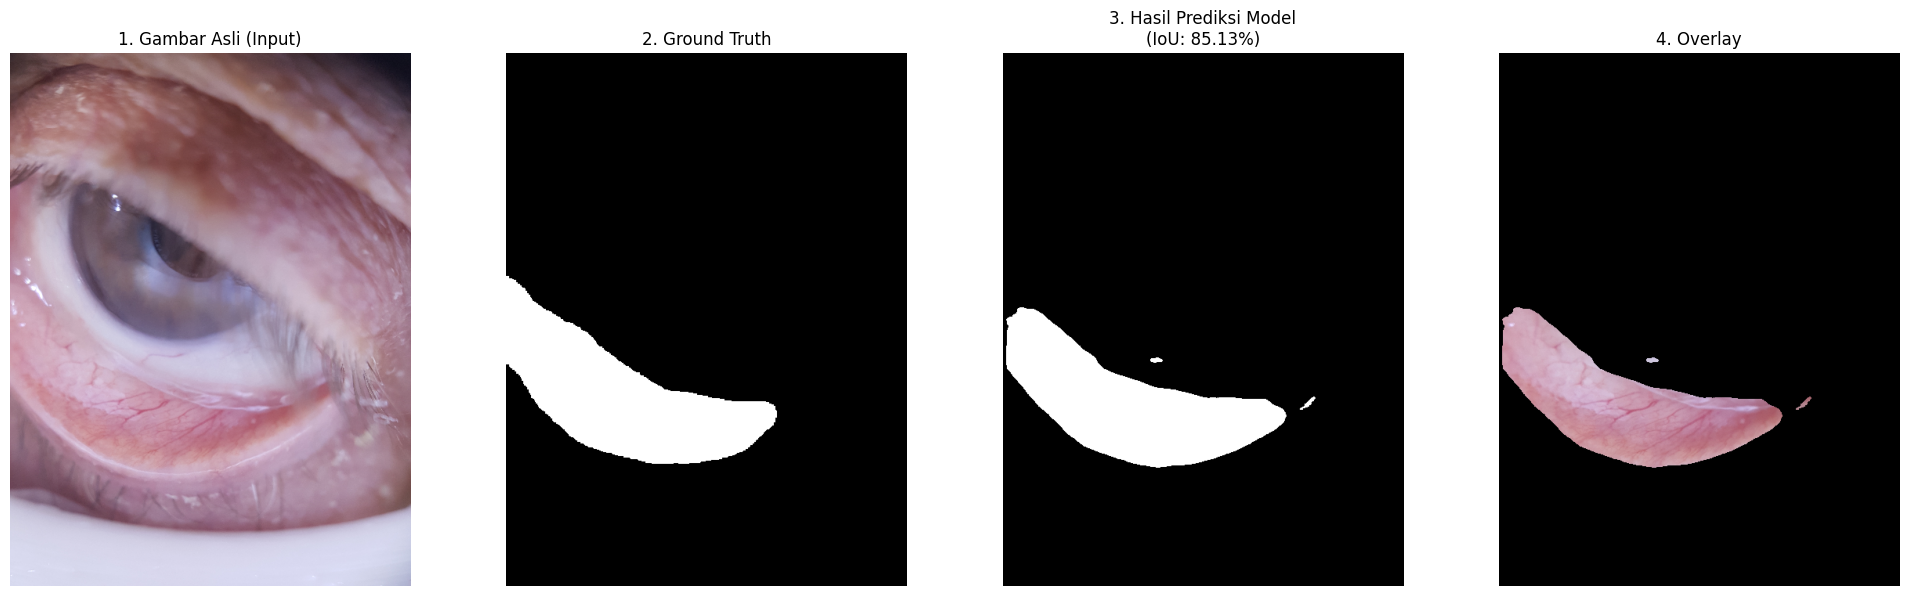

In [ ]:
plt.figure(figsize=(20, 6))

plt.subplot(1, 4, 1)
plt.title('1. Gambar Asli (Input)')
plt.imshow(img_resized) # udah rgb dr read_img2
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title('2. Ground Truth')
plt.imshow(gt_mask_biner, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title(f'3. Hasil Prediksi Model\n(IoU: {iou_score * 100:.2f}%)')
plt.imshow(pred_mask_2d, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title('4. Overlay')
plt.imshow(blended_pred)
plt.axis('off')

plt.tight_layout()
plt.show()

### Analisis Hasil Training

### (Distribusi IoU Score, Min-Max IoU Value)
#### **Run dulu Cell Define Path Dataset**

In [ ]:
EYEDEFY_ROOT = os.path.join(PROJECT_ROOT, "dataset", "Dataset Eyedefy")
all_images, all_masks = get_eyedefy_paths(EYEDEFY_ROOT)

#runtutannya harus sama kayak training (ga semua gambar jadi data validasi)
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    all_images, all_masks, test_size=0.2, random_state=42
)

print(f"Total seluruh data  : {len(all_images)}")
print(f"Total data validasi : {len(val_imgs)}")

Total seluruh data  : 211
Total data validasi : 43


Analyze IoU Score...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 

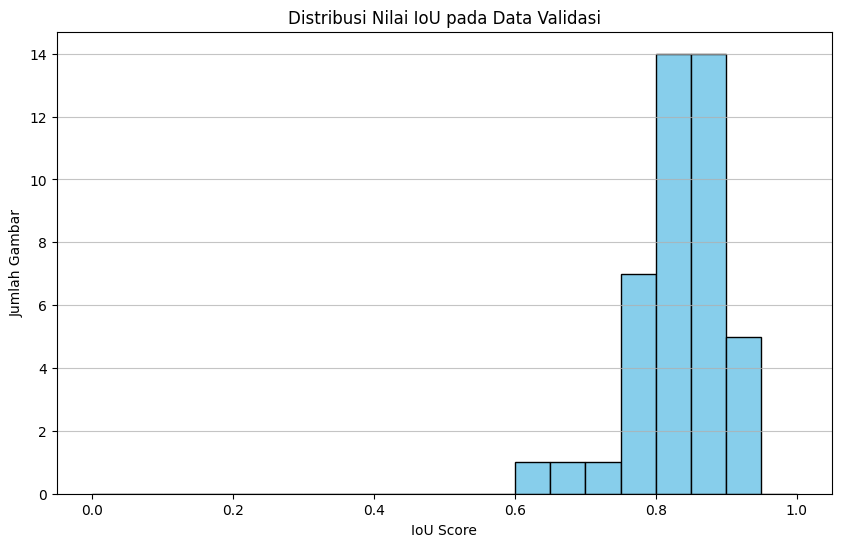

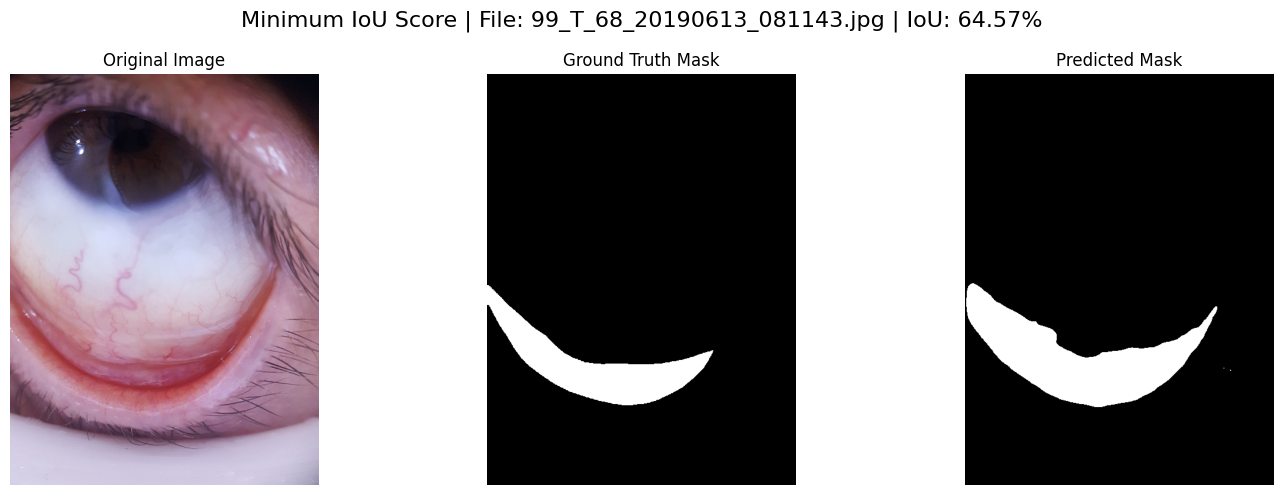

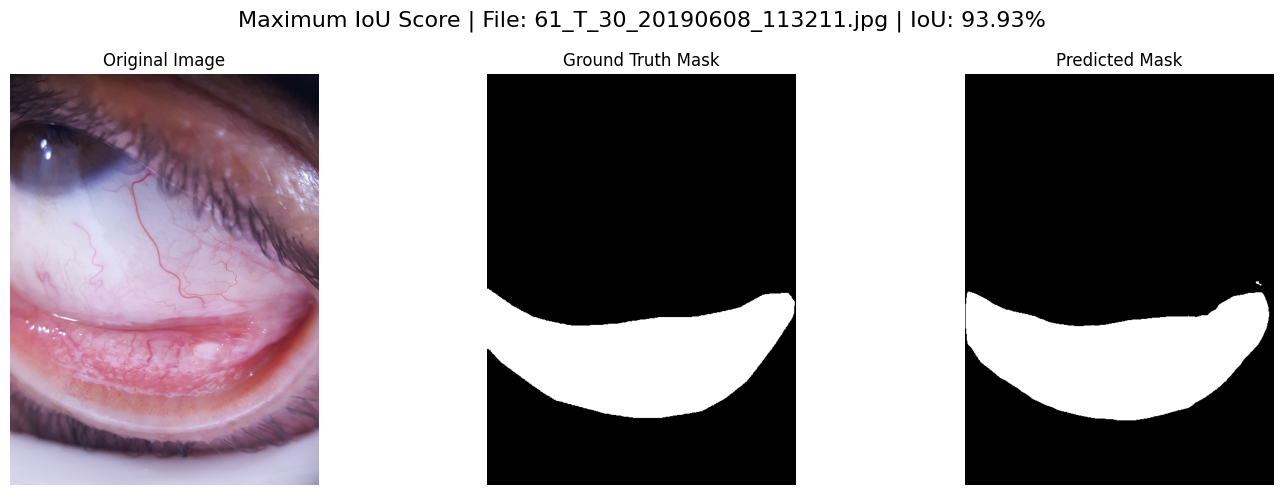


File disimpan di folder: /content/drive/MyDrive/Keperluan TA/models/weights/simulasi/Hasil_Training_wParameters1


In [ ]:
result_path = "/content/drive/MyDrive/Keperluan TA/models/weights/simulasi"
nama_folder = os.path.join(result_path, "Hasil_Training_wParameters1")
os.makedirs(nama_folder, exist_ok=True)

iou_list = []
eval_results = []

print("Analyze IoU Score...")
for idx, (img_path, mask_path) in enumerate(zip(val_imgs, val_masks)):

    img_resized, _, pred_mask, _ = read_image2(model, img_path)
    pred_mask_2d = np.squeeze(pred_mask, axis=-1)

    mask_img = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    if mask_img.dtype == np.uint16:
        mask_img = (mask_img / 256).astype(np.uint8)

    if len(mask_img.shape) == 3 and mask_img.shape[2] == 4:
        mask_img = cv2.cvtColor(mask_img, cv2.COLOR_BGRA2RGBA)

    else :
        mask_img = cv2.cvtColor(mask_img, cv2.COLOR_BGR2RGB)

    mask_hsv = cv2.cvtColor(mask_img, cv2.COLOR_RGB2HSV)

    saturation = mask_hsv[:, :, 1]

    if np.min(mask_img) == 0:
        _, gt_mask = cv2.threshold(mask_img[:, :, 3], 0, 255, cv2.THRESH_BINARY)

    else:
        _, gt_mask = cv2.threshold(saturation, 1, 255, cv2.THRESH_BINARY)

    kernel = np.ones((6,6), np.uint8)
    gt_mask = cv2.morphologyEx(gt_mask, cv2.MORPH_CLOSE, kernel)

    gt_mask_resized = cv2.resize(gt_mask, (512, 682), interpolation=cv2.INTER_NEAREST)
    gt_mask_biner = (gt_mask_resized > 0).astype(np.uint8)

    intersection = np.logical_and(gt_mask_biner, pred_mask_2d)
    union = np.logical_or(gt_mask_biner, pred_mask_2d)
    iou_score = np.sum(intersection) / np.sum(union) if np.sum(union) != 0 else 0

    iou_list.append(iou_score)

    unique_name = f"{os.path.basename(os.path.dirname(img_path))}_{os.path.basename(img_path)}"

    eval_results.append({
        'img_name': unique_name,
        'iou': iou_score,
        'img': img_resized,
        'gt': gt_mask_biner,
        'pred': pred_mask_2d
    })

#visualisasi distribusi IoU
plt.figure(figsize=(10, 6))
plt.hist(iou_list, bins=20, range=(0, 1), color='skyblue', edgecolor='black')
plt.title('Distribusi Nilai IoU pada Data Validasi')
plt.xlabel('IoU Score')
plt.ylabel('Jumlah Gambar')
plt.grid(axis='y', alpha=0.75)
plt.savefig(os.path.join(nama_folder, "Distribusi_IoU.png"))
plt.show()

# plotting min-max
eval_results_sorted = sorted(eval_results, key=lambda x: x['iou'])
iou_min = eval_results_sorted[0]
iou_max = eval_results_sorted[-1]

def plot_min_max(data_dict, title_prefix, filename):
    plt.figure(figsize=(15, 5))
    plt.suptitle(f"{title_prefix} | File: {data_dict['img_name']} | IoU: {data_dict['iou']*100:.2f}%", fontsize=16)

    plt.subplot(1, 3, 1)
    plt.title('Original Image')
    plt.imshow(data_dict['img'])
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title('Ground Truth Mask')
    plt.imshow(data_dict['gt'], cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title('Predicted Mask')
    plt.imshow(data_dict['pred'], cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(nama_folder, filename))
    plt.show()

plot_min_max(iou_min, "Minimum IoU Score", "Minimum IoU Score.png")
plot_min_max(iou_max, "Maximum IoU Score", "Maximum IoU Score.png")

print(f"\nFile disimpan di folder: {nama_folder}")